# Day 38: Trees & SVM Assessment
**Author:** Sahil-K-Y  
**Phase:** 3 - Tree Models & SVM  
**Date:** Day 038

---

## 1. Master Classification Algorithms Comparison Matrix

| Algorithm | Boundaries | Outlier Sensitivity | Training Complexity | Scaling Dependency | Key Hyperparameters |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Decision Trees** | Discontinuous Splits | Low (Robust) | $O(d \cdot N \log N)$ | No | `max_depth`, `min_samples_split` |
| **SVM (RBF)** | Smooth Curves | High (due to SVs) | $O(N^2 \cdot d)$ to $O(N^3)$ | Yes (Absolute) | `C`, `gamma` |
| **KNN** | Complex Local | High | $O(1)$ | Yes (Absolute) | `n_neighbors`, `weights` |
| **Naive Bayes** | Hyperplane | Low (Robust) | $O(N \cdot d)$ | No | `alpha` |
| **Random Forest** | Highly complex | Low (Robust) | $O(B \cdot d \cdot N \log N)$ | No | `n_estimators`, `max_depth` |

## 2. Written Assessment: 20 Advanced ML Interview Questions

1. **Why does CART algorithm use Gini impurity over Information Gain by default?**
   - **Answer**: Gini impurity does not require logarithmic calculations like Shannon Entropy does (i.e. $-p \log_2 p$). Removing logarithms reduces computational latency significantly during split evaluations.
2. **Derive Gini impurity and Shannon entropy for binary variables.**
   - **Answer**: Gini: $I_G(p) = 1 - (p^2 + (1-p)^2) = 2p(1-p)$. Entropy: $H(p) = -p \log_2(p) - (1-p) \log_2(1-p)$.
3. **How do constraints like `min_samples_leaf` control tree variance?**
   - **Answer**: Prevents nodes from splitting on very specific training samples or individual outliers, reducing tree depth and curbing variance.
4. **Explain the cost complexity function of Cost-Complexity Pruning (CCP).**
   - **Answer**: CCP minimizes $R_\alpha(T) = R(T) + \alpha |T|$, where $R(T)$ is validation error, $|T|$ is tree size, and $\alpha$ controls complexity penalty. High $\alpha$ yields smaller, pruned trees.
5. **How does the splitting criterion change from classification to regression trees?**
   - **Answer**: Classification splits minimize impurity (Gini/Entropy). Regression splits minimize variance or Mean Squared Error (MSE): $\sum_{L} (y_i - \bar{y}_L)^2 + \sum_{R} (y_i - \bar{y}_R)^2$.
6. **Derive the margin width $2/\|w\|$ for a Hard-Margin SVM.**
   - **Answer**: Supporting planes are defined as $w^T x_+ + b = 1$ and $w^T x_- + b = -1$. The distance projection along unit vector $\frac{w}{\parallel w \parallel}$ is $\frac{w^T(x_+ - x_-)}{\parallel w \parallel} = \frac{(1-b) - (-1-b)}{\parallel w \parallel} = \frac{2}{\parallel w \parallel}$.
7. **Write the objective function of Soft-Margin SVM using slack variables $\xi_i$.**
   - **Answer**: $\min_{w,b,\xi} \frac{1}{2}\|w\|^2 + C \sum \xi_i$ subject to $y_i(w^T x_i + b) \ge 1 - \xi_i, \xi_i \ge 0$.
8. **What is the physical and mathematical meaning of $C$ regularization in SVM?**
   - **Answer**: $C$ scales the penalty of margin violations. When $C \to \infty$, violations are forbidden (Hard-Margin SVM). Low $C$ encourages wider margins, increasing bias but decreasing variance.
9. **Why do we solve the dual problem of SVM instead of the primal problem?**
   - **Answer**: The dual formulation optimizes Lagrange multipliers $\alpha_i$ and depends only on dot products $x_i^T x_j$, allowing the Kernel Trick to map inputs into infinite-dimensional spaces.
10. **State Mercer's Theorem and how it enables linear separation in high-dimensional spaces.**
    - **Answer**: Mercer's Theorem states any symmetric positive semi-definite kernel $K(x,y)$ can be represented as an inner product $\Phi(x)^T \Phi(y)$, allowing SVM to calculate high-dimensional margins without computing $\Phi(x)$ explicitly.
11. **Explain the role of the $\gamma$ parameter in the RBF kernel.**
    - **Answer**: RBF: $K(x,y) = \exp(-\gamma \|x-y\|^2)$. $\gamma$ defines the radius of influence of support vectors. High $\gamma$ limits influence, creating complex, tight decision boundaries.
12. **Compare Euclidean, Manhattan, and Minkowski distance metrics.**
    - **Answer**: Minkowski: $d(x,y) = (\sum |x_i - y_i|^p)^{1/p}$. $p=2$ yields Euclidean distance (straight-line), and $p=1$ yields Manhattan distance (grid-like).
13. **Why does KNN fail in high-dimensional spaces mathematically?**
    - **Answer**: Due to the Curse of Dimensionality, as dimension $d \to \infty$, the volume of space scales exponentially. Points become nearly equidistant ($d_{\max} - d_{\min} \to 0$), making distance-based classification arbitrary.
14. **Why is feature scaling strictly required for KNN?**
    - **Answer**: KNN computes distances. Unscaled features with larger ranges dominate distance equations, rendering small-scale features useless in metric distance groupings.
15. **Contrast hard voting and soft voting in ensembles.**
    - **Answer**: Hard voting sums raw predicted class counts. Soft voting averages the predicted class probabilities from each estimator, giving weight to high-confidence models.
16. **Prove mathematically how bagging reduces ensemble variance.**
    - **Answer**: Ensemble average variance is $\text{Var}(\bar{X}) = \rho\sigma^2 + \frac{1-\rho}{B}\sigma^2$. As $B \to \infty$, the second term goes to 0, bounding ensemble variance by $\rho\sigma^2$, which is lower than a single tree's variance $\sigma^2$ (since $\rho < 1$).
17. **Prove that a bootstrap sample contains approximately $63.2\%$ of the original data.**
    - **Answer**: Probability of *not* selecting a sample in one draw is $1 - 1/N$. In $N$ draws, probability is $(1 - 1/N)^N$. As $N \to \infty$, this limit converges to $1/e \approx 0.368$. Thus, probability of being selected is $1 - 0.368 = 63.2\%$.
18. **Why does Random Forest perform column sampling at each node split?**
    - **Answer**: Standard bagging has highly correlated trees because dominant features are selected first. Node-level column sampling decorrelates trees, reducing correlation $\rho$ and lowering ensemble variance.
19. **Explain why MDI is biased towards high-cardinality features.**
    - **Answer**: Continuous or high-cardinality features present many split positions. Greedy split metrics select them repeatedly during training, inflating their impurity reduction score regardless of true prediction value.
20. **In what scenarios would you choose Logistic Regression over SVM or Decision Trees for real-time inference?**
    - **Answer**: When inference latency must be extremely low (sub-millisecond) or memory footprint is strictly restricted. Logistic Regression computes predictions via a simple dot product $w^T x$ and sigmoid mapping, requiring minimal memory and execution loops.

## Exercise 1: Benchmarking Decision Boundaries on Non-linear Datasets

We will evaluate and compare the decision boundaries of Decision Trees, RBF SVM, and KNN classifiers on a non-linear moons dataset.

### Step 1.1: Generating and Scaling Moon Shapes Dataset

In [4]:
import numpy as np
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import pandas as pd
# 1. Generate non-linear moons dataset (noise=0.3 se data thoda realistic banega)
X, y = make_moons(n_samples=500, noise=0.3, random_state=42)

# 2. Scale features using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Moons Dataset Generated! Shape: X = {X_scaled.shape}, y = {y.shape}")

Moons Dataset Generated! Shape: X = (500, 2), y = (500,)


In [5]:
df=pd.DataFrame(X)

<Axes: xlabel='0', ylabel='1'>

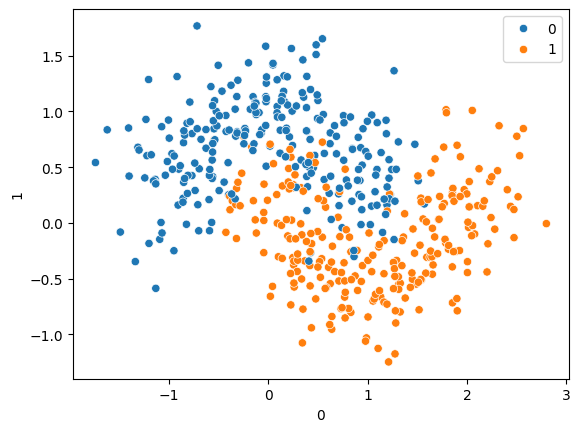

In [8]:
sns.scatterplot(df,x=0,y=1,hue=y)

<Axes: >

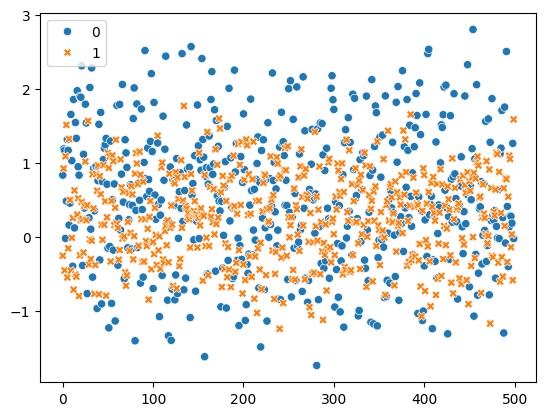

In [9]:
sns.scatterplot(df)

<Axes: ylabel='Count'>

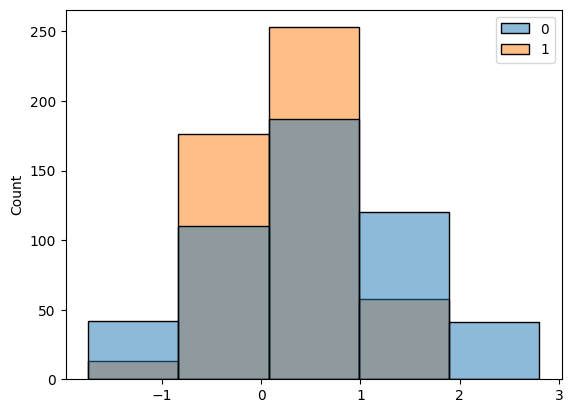

In [10]:
sns.histplot(df,bins=5)

### Step 1.2: Train-Test Split

In [16]:
from sklearn.model_selection import train_test_split

# Perform train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"Train Shape: {X_train.shape} | Test Shape: {X_test.shape}")

Train Shape: (400, 2) | Test Shape: (100, 2)


### Step 1.3: Fitting DecisionTree, SVM, and KNN Classifiers

In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# 1. Initialize models
dt_clf = DecisionTreeClassifier(max_depth=5, random_state=42)
svm_clf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
knn_clf = KNeighborsClassifier(n_neighbors=7)

# 2. Train all models
dt_clf.fit(X_train, y_train)
svm_clf.fit(X_train, y_train)
knn_clf.fit(X_train, y_train)

print("Teeno Classifiers (Decision Tree, SVM, KNN) successfully train ho gaye hain!")

Teeno Classifiers (Decision Tree, SVM, KNN) successfully train ho gaye hain!


### Step 1.4: Evaluating Model Test Accuracy

In [18]:
from sklearn.metrics import accuracy_score

# Predict on test data
dt_acc = accuracy_score(y_test, dt_clf.predict(X_test))
svm_acc = accuracy_score(y_test, svm_clf.predict(X_test))
knn_acc = accuracy_score(y_test, knn_clf.predict(X_test))

print("--- Test Accuracy Comparison ---")
print(f"1. Decision Tree Accuracy: {dt_acc:.4f}")
print(f"2. SVM (RBF) Accuracy:     {svm_acc:.4f}")
print(f"3. KNN Accuracy:           {knn_acc:.4f}")

--- Test Accuracy Comparison ---
1. Decision Tree Accuracy: 0.9000
2. SVM (RBF) Accuracy:     0.8500
3. KNN Accuracy:           0.8800


### Step 1.5: Plotting Decision Surfaces Side-by-Side

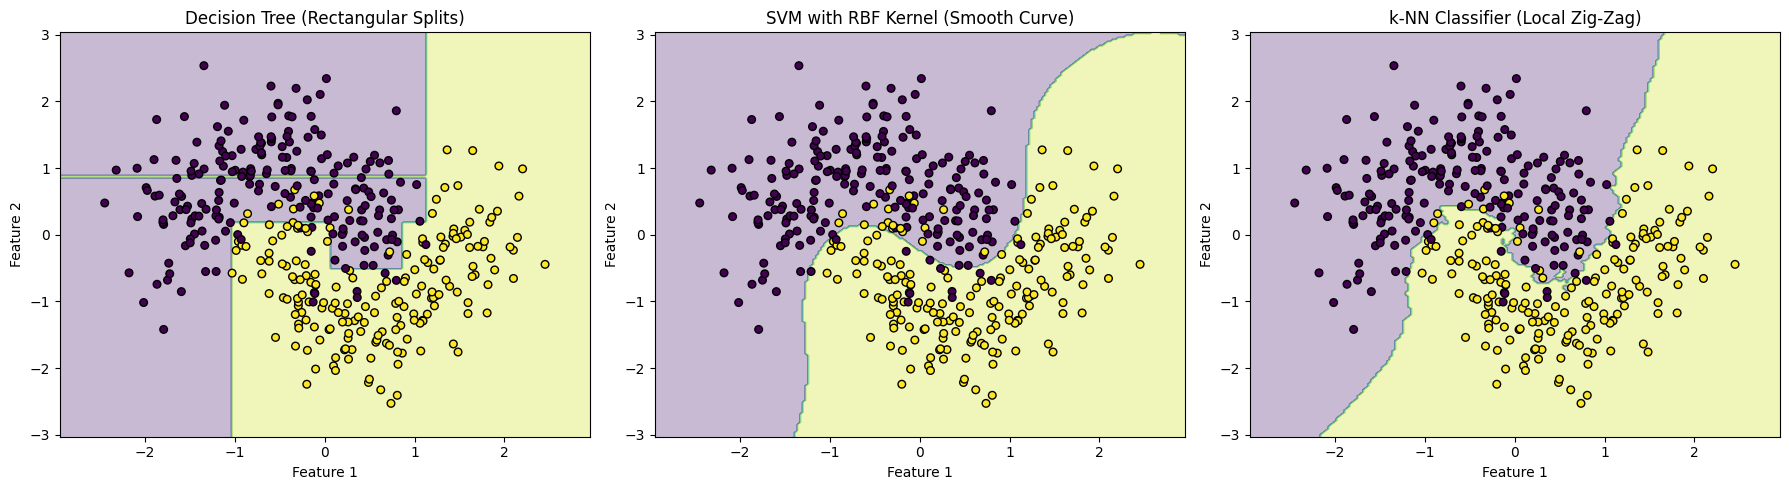

In [19]:
import matplotlib.pyplot as plt

# Meshgrid banate hain poore graph par points test karne ke liye
x_min, x_max = X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5
y_min, y_max = X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

# Teeno models aur unke titles ki list
classifiers = [dt_clf, svm_clf, knn_clf]
titles = ['Decision Tree (Rectangular Splits)', 
          'SVM with RBF Kernel (Smooth Curve)', 
          'k-NN Classifier (Local Zig-Zag)']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, clf, title in zip(axes, classifiers, titles):
    # Predict mesh grid points
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot contour boundary
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
    
    # Plot actual training data points
    scatter = ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='viridis', edgecolors='k', s=30)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

plt.tight_layout()
plt.show()